# AI-Driven Student Performance Prediction System

**Complete Google Colab project** for predicting student GPA from academic, behavioral, and support-related features.

**Official regression metrics:** R², MAE, RMSE.

**User-friendly metric:** percentage of predictions within a chosen GPA tolerance.

## End-to-end workflow

Data upload → inspection → cleaning → EDA → feature selection → train/test split → multiple regression models → train/test comparison → final model → error analysis → feature interpretation → GPA prediction → risk level → recommendations → model export.

In [1]:
# Cell 1: Install required package
%pip -q install xgboost joblib

In [2]:
# Cell 2: Imports
import os
import joblib
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Cell 3: Locate or upload the CSV
DATA_PATH = '/content/AI_Student_Performance_100K_Synthetic.csv'

if not os.path.exists(DATA_PATH):
    from google.colab import files
    print('CSV not found in /content. Please upload the dataset file.')
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = '/content/' + uploaded_name

print('Dataset path:', DATA_PATH)

Dataset path: /content/AI_Student_Performance_100K_Synthetic.csv


In [4]:
# Cell 4: Load dataset
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (100000, 18)


,StudentID,Age,StudyHoursPerWeek,AttendanceRate,AssignmentCompletionRate,PreviousGPA,TestAverage,ClassParticipation,HomeworkHoursPerWeek,SleepHoursPerDay,ScreenTimeHoursPerDay,ParentalSupport,MotivationLevel,StressLevel,Tutoring,ExtracurricularActivities,InternetAccess,GPA
0,STU000001,16,17.9,82.8,74.7,2.53,90.3,45.4,6.8,7.9,1.0,2,6,1,1,1,1,2.42
1,STU000002,16,17.6,95.9,77.5,3.20,76.5,70.9,5.5,6.2,1.0,3,2,10,0,1,1,2.58
2,STU000003,16,18.7,80.1,85.5,3.21,69.1,73.8,5.2,7.2,5.3,4,5,3,0,0,1,2.68
3,STU000004,17,20.1,91.8,88.1,3.04,74.7,79.2,1.3,7.3,7.2,4,9,7,0,1,1,3.06
4,STU000005,19,20.8,88.4,81.6,2.39,79.4,70.6,10.6,7.6,5.5,4,6,5,0,1,1,2.19


In [5]:
# Cell 5: Basic information
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Column names:')
print(df.columns.tolist())

Rows: 100000
Columns: 18
Column names:
['StudentID', 'Age', 'StudyHoursPerWeek', 'AttendanceRate', 'AssignmentCompletionRate', 'PreviousGPA', 'TestAverage', 'ClassParticipation', 'HomeworkHoursPerWeek', 'SleepHoursPerDay', 'ScreenTimeHoursPerDay', 'ParentalSupport', 'MotivationLevel', 'StressLevel', 'Tutoring', 'ExtracurricularActivities', 'InternetAccess', 'GPA']


In [6]:
# Cell 6: Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   StudentID                  100000 non-null  object 
 1   Age                        100000 non-null  int64  
 2   StudyHoursPerWeek          100000 non-null  float64
 3   AttendanceRate             100000 non-null  float64
 4   AssignmentCompletionRate   100000 non-null  float64
 5   PreviousGPA                100000 non-null  float64
 6   TestAverage                100000 non-null  float64
 7   ClassParticipation         100000 non-null  float64
 8   HomeworkHoursPerWeek       100000 non-null  float64
 9   SleepHoursPerDay           100000 non-null  float64
 10  ScreenTimeHoursPerDay      100000 non-null  float64
 11  ParentalSupport            100000 non-null  int64  
 12  MotivationLevel            100000 non-null  int64  
 13  StressLevel                100

In [7]:
# Cell 7: Missing values
missing_report = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().mean() * 100).round(2)
})
missing_report

,Missing_Count,Missing_Percentage
StudentID,0,0.0
Age,0,0.0
StudyHoursPerWeek,0,0.0
AttendanceRate,0,0.0
AssignmentCompletionRate,0,0.0
PreviousGPA,0,0.0
TestAverage,0,0.0
ClassParticipation,0,0.0
HomeworkHoursPerWeek,0,0.0
SleepHoursPerDay,0,0.0


In [8]:
# Cell 8: Duplicate rows
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicate removal:', df.shape)

Duplicate rows: 0
Shape after duplicate removal: (100000, 18)


In [9]:
# Cell 9: Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,100000,100000,STU099984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100000.0,NaN,NaN,NaN,18.51413,2.290173,15.0,17.0,19.0,21.0,22.0
StudyHoursPerWeek,100000.0,NaN,NaN,NaN,14.010231,5.877554,2.0,9.9,14.0,18.0,35.0
AttendanceRate,100000.0,NaN,NaN,NaN,83.869053,8.673905,50.0,78.0,84.0,90.0,100.0
AssignmentCompletionRate,100000.0,NaN,NaN,NaN,81.769173,10.528494,40.0,74.6,82.0,89.4,100.0
PreviousGPA,100000.0,NaN,NaN,NaN,2.747012,0.543517,1.0,2.38,2.75,3.12,4.0
TestAverage,100000.0,NaN,NaN,NaN,71.842895,13.680718,25.0,62.5,72.0,81.4,100.0
ClassParticipation,100000.0,NaN,NaN,NaN,71.866054,13.725088,20.0,62.6,72.0,81.4,100.0
HomeworkHoursPerWeek,100000.0,NaN,NaN,NaN,7.498483,3.180231,0.0,5.3,7.5,9.6,20.0
SleepHoursPerDay,100000.0,NaN,NaN,NaN,7.095704,0.994144,4.0,6.4,7.1,7.8,10.0


In [10]:
# Cell 10: Target statistics
print(df['GPA'].describe())
print('GPA min:', df['GPA'].min())
print('GPA max:', df['GPA'].max())
print('GPA mean:', df['GPA'].mean())

count    100000.000000
mean          2.229081
std           0.419414
min           0.470000
25%           1.940000
50%           2.230000
75%           2.520000
max           3.870000
Name: GPA, dtype: float64
GPA min: 0.47
GPA max: 3.87
GPA mean: 2.2290812


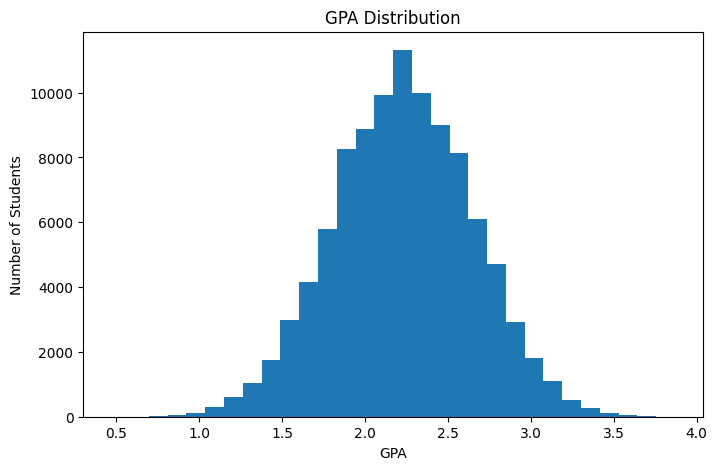

In [11]:
# Cell 11: GPA distribution
plt.figure(figsize=(8, 5))
plt.hist(df['GPA'].dropna(), bins=30)
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.title('GPA Distribution')
plt.show()

In [12]:
# Cell 12: Correlation with GPA
correlation = df.corr(numeric_only=True)['GPA'].sort_values(ascending=False)
correlation

,GPA
GPA,1.000000
PreviousGPA,0.622412
TestAverage,0.326530
AssignmentCompletionRate,0.250742
AttendanceRate,0.250284
MotivationLevel,0.168801
ClassParticipation,0.166603
StudyHoursPerWeek,0.141404
ParentalSupport,0.066627
Tutoring,0.025801


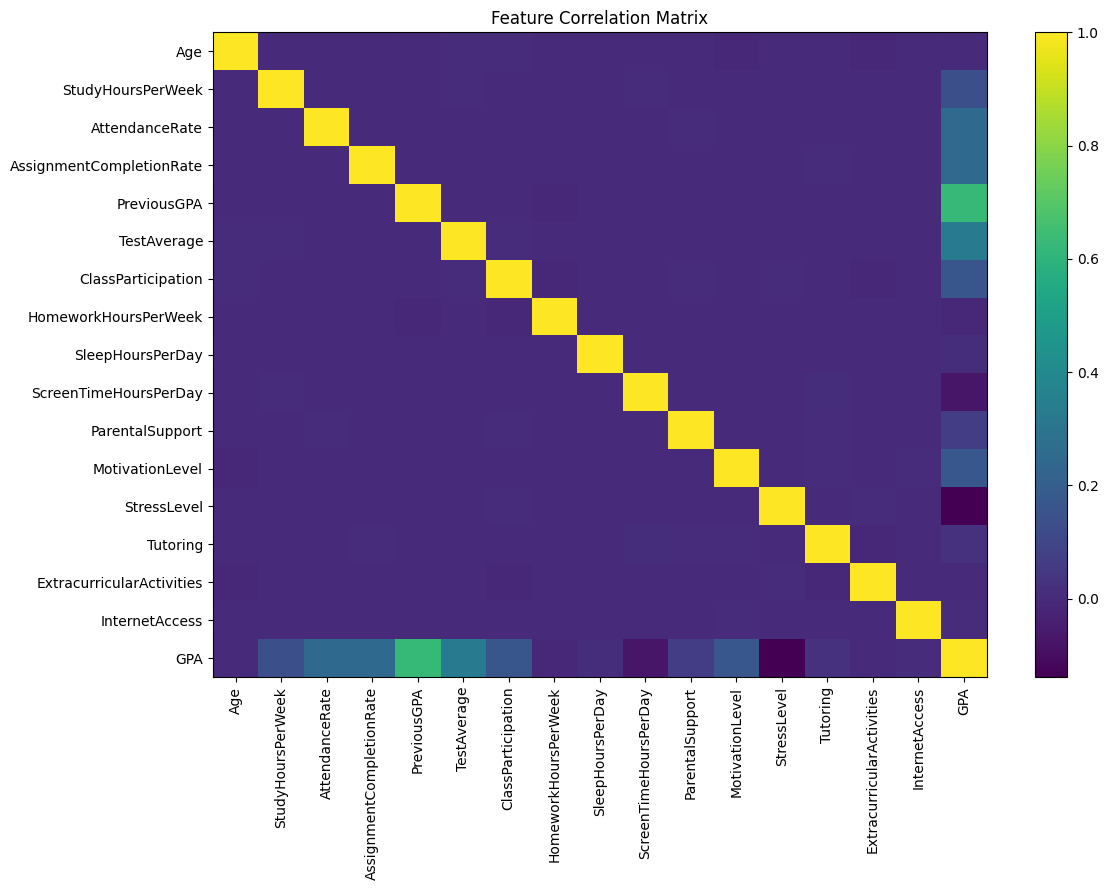

In [13]:
# Cell 13: Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Data preparation

`StudentID` is only an identifier and is excluded. `GPA` is the target. The remaining 16 numeric attributes are the input features. Missing input values are handled inside model pipelines so the same preprocessing is used during prediction.

In [14]:
# Cell 14: Define features and target
TARGET = 'GPA'
FEATURES = [
    'Age',
    'StudyHoursPerWeek',
    'AttendanceRate',
    'AssignmentCompletionRate',
    'PreviousGPA',
    'TestAverage',
    'ClassParticipation',
    'HomeworkHoursPerWeek',
    'SleepHoursPerDay',
    'ScreenTimeHoursPerDay',
    'ParentalSupport',
    'MotivationLevel',
    'StressLevel',
    'Tutoring',
    'ExtracurricularActivities',
    'InternetAccess'
]

print('Number of features:', len(FEATURES))
print(FEATURES)

Number of features: 16
['Age', 'StudyHoursPerWeek', 'AttendanceRate', 'AssignmentCompletionRate', 'PreviousGPA', 'TestAverage', 'ClassParticipation', 'HomeworkHoursPerWeek', 'SleepHoursPerDay', 'ScreenTimeHoursPerDay', 'ParentalSupport', 'MotivationLevel', 'StressLevel', 'Tutoring', 'ExtracurricularActivities', 'InternetAccess']


In [15]:
# Cell 15: Build X and y
model_df = df[FEATURES + [TARGET]].copy()
model_df = model_df[model_df[TARGET].notna()].reset_index(drop=True)

X = model_df[FEATURES]
y = model_df[TARGET]

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (100000, 16)
y shape: (100000,)


In [16]:
# Cell 16: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 80000
Testing samples : 20000


## Model 1: Linear Regression

In [17]:
# Cell 17: Train Linear Regression
linear_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)
print('Linear Regression trained.')

Linear Regression trained.


## Model 2: Ridge Regression

In [18]:
# Cell 18: Train Ridge Regression
ridge_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)
print('Ridge Regression trained.')

Ridge Regression trained.


## Model 3: Random Forest

In [19]:
# Cell 19: Train Random Forest
rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
print('Random Forest trained.')

Random Forest trained.


## Model 4: Gradient Boosting

In [20]:
# Cell 20: Train Gradient Boosting
gb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gb_model.fit(X_train, y_train)
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)
print('Gradient Boosting trained.')

Gradient Boosting trained.


## Model 5: XGBoost

In [21]:
# Cell 21: Train XGBoost
xgb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.01,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
print('XGBoost trained.')

XGBoost trained.


## Model evaluation

In [22]:
# Cell 22: Evaluation function
def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

model_store = {
    'Linear Regression': (linear_model, linear_train_pred, linear_test_pred),
    'Ridge Regression': (ridge_model, ridge_train_pred, ridge_test_pred),
    'Random Forest': (rf_model, rf_train_pred, rf_test_pred),
    'Gradient Boosting': (gb_model, gb_train_pred, gb_test_pred),
    'XGBoost': (xgb_model, xgb_train_pred, xgb_test_pred)
}

print('Evaluation function ready.')

Evaluation function ready.


In [23]:
# Cell 23: Train vs test metrics for every model
rows = []
for name, (_, train_pred, test_pred) in model_store.items():
    train_m = metrics(y_train, train_pred)
    test_m = metrics(y_test, test_pred)
    rows.append({
        'Model': name,
        'Train_R2': train_m['R2'],
        'Test_R2': test_m['R2'],
        'R2_Gap': train_m['R2'] - test_m['R2'],
        'Train_MAE': train_m['MAE'],
        'Test_MAE': test_m['MAE'],
        'Train_RMSE': train_m['RMSE'],
        'Test_RMSE': test_m['RMSE']
    })

results = pd.DataFrame(rows).sort_values('Test_R2', ascending=False).reset_index(drop=True)
results.round(6)

,Model,Train_R2,Test_R2,R2_Gap,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE
0,Ridge Regression,0.725770,0.721410,0.004360,0.175233,0.175998,0.219800,0.220699
1,Linear Regression,0.725770,0.721409,0.004360,0.175232,0.175998,0.219800,0.220699
2,XGBoost,0.741695,0.716251,0.025444,0.170103,0.177532,0.213322,0.222733
3,Gradient Boosting,0.724191,0.708696,0.015495,0.175749,0.179864,0.220432,0.225679
4,Random Forest,0.927014,0.688557,0.238457,0.087986,0.186140,0.113394,0.233349


In [24]:
# Cell 24: Best model
best_model_name = results.loc[0, 'Model']
best_model = model_store[best_model_name][0]
best_train_pred = model_store[best_model_name][1]
best_test_pred = model_store[best_model_name][2]

print('Best model:', best_model_name)
print(results.round(6))

Best model: Ridge Regression
               Model  Train_R2   Test_R2    R2_Gap  Train_MAE  Test_MAE  \
0   Ridge Regression  0.725770  0.721410  0.004360   0.175233  0.175998   
1  Linear Regression  0.725770  0.721409  0.004360   0.175232  0.175998   
2            XGBoost  0.741695  0.716251  0.025444   0.170103  0.177532   
3  Gradient Boosting  0.724191  0.708696  0.015495   0.175749  0.179864   
4      Random Forest  0.927014  0.688557  0.238457   0.087986  0.186140   

   Train_RMSE  Test_RMSE  
0    0.219800   0.220699  
1    0.219800   0.220699  
2    0.213322   0.222733  
3    0.220432   0.225679  
4    0.113394   0.233349  


In [25]:
# Cell 25: Final test metrics
final_metrics = metrics(y_test, best_test_pred)

print('=' * 60)
print('FINAL TEST PERFORMANCE')
print('=' * 60)
print('Model:', best_model_name)
print(f"R²   : {final_metrics['R2']:.4f}")
print(f"MAE  : {final_metrics['MAE']:.4f}")
print(f"RMSE : {final_metrics['RMSE']:.4f}")

FINAL TEST PERFORMANCE
Model: Ridge Regression
R²   : 0.7214
MAE  : 0.1760
RMSE : 0.2207


## Easy-to-read prediction accuracy

GPA prediction is a regression problem, so `accuracy_score` is not appropriate. This custom metric reports the percentage of test predictions that fall within a chosen GPA error tolerance.

In [26]:
# Cell 26: Tolerance accuracy
def tolerance_accuracy(y_true, y_pred, tolerance):
    error = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.mean(error <= tolerance) * 100)

for tolerance in [0.10, 0.20, 0.30, 0.50]:
    print(f"Within ±{tolerance:.2f} GPA: {tolerance_accuracy(y_test, best_test_pred, tolerance):.2f}%")

Within ±0.10 GPA: 35.30%
Within ±0.20 GPA: 63.59%
Within ±0.30 GPA: 82.33%
Within ±0.50 GPA: 97.76%


In [27]:
# Cell 27: Actual vs predicted table
prediction_table = pd.DataFrame({
    'Actual_GPA': y_test.to_numpy(),
    'Predicted_GPA': best_test_pred
})
prediction_table['Error'] = prediction_table['Actual_GPA'] - prediction_table['Predicted_GPA']
prediction_table['Absolute_Error'] = prediction_table['Error'].abs()
prediction_table.head(20)

,Actual_GPA,Predicted_GPA,Error,Absolute_Error
0,1.50,1.490046,0.009954,0.009954
1,1.98,2.057621,-0.077621,0.077621
2,2.35,2.262537,0.087463,0.087463
3,2.51,2.762347,-0.252347,0.252347
4,2.06,1.909989,0.150011,0.150011
5,2.21,1.970598,0.239402,0.239402
6,1.63,1.765945,-0.135945,0.135945
7,1.83,1.917130,-0.087130,0.087130
8,2.72,2.718577,0.001423,0.001423
9,2.14,2.700572,-0.560572,0.560572


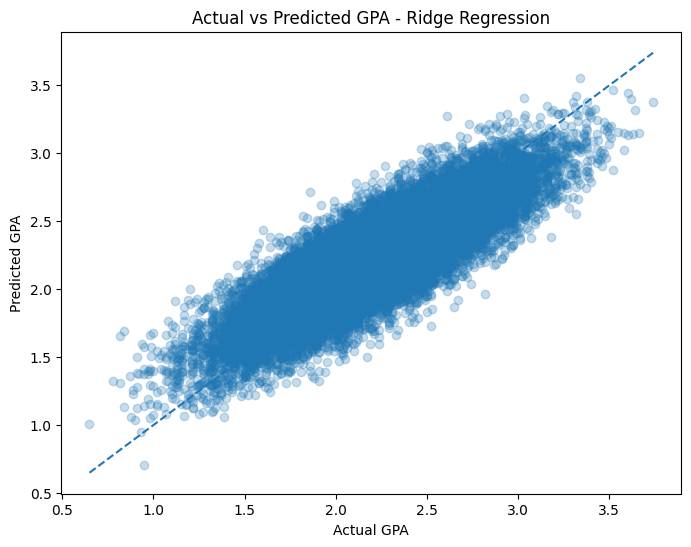

In [28]:
# Cell 28: Actual vs predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(prediction_table['Actual_GPA'], prediction_table['Predicted_GPA'], alpha=0.25)
min_value = min(prediction_table['Actual_GPA'].min(), prediction_table['Predicted_GPA'].min())
max_value = max(prediction_table['Actual_GPA'].max(), prediction_table['Predicted_GPA'].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title(f'Actual vs Predicted GPA - {best_model_name}')
plt.show()

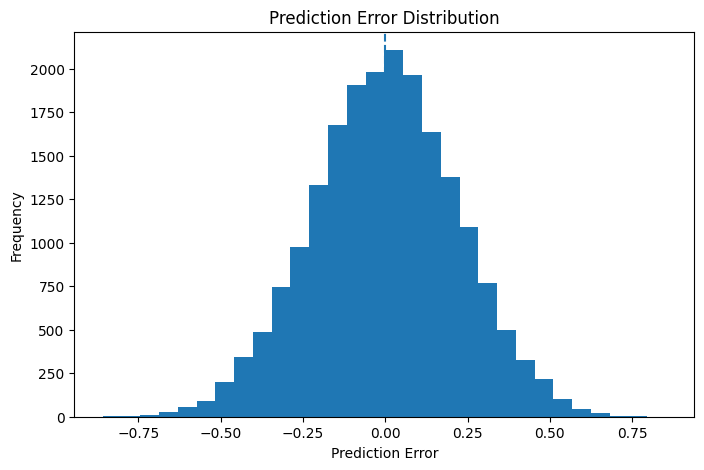

In [29]:
# Cell 29: Error distribution
plt.figure(figsize=(8, 5))
plt.hist(prediction_table['Error'], bins=30)
plt.axvline(0, linestyle='--')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.show()

In [30]:
# Cell 30: Best and worst predictions
print('Largest errors:')
display(prediction_table.sort_values('Absolute_Error', ascending=False).head(10))

Largest errors:


,Actual_GPA,Predicted_GPA,Error,Absolute_Error
15091,1.86,2.718423,-0.858423,0.858423
14414,2.82,1.966705,0.853295,0.853295
13792,0.84,1.690902,-0.850902,0.850902
3826,1.60,2.436328,-0.836328,0.836328
9100,0.82,1.653977,-0.833977,0.833977
11612,1.20,2.003480,-0.803480,0.803480
4948,2.52,1.725816,0.794184,0.794184
15517,3.18,2.387609,0.792391,0.792391
10520,1.12,1.911366,-0.791366,0.791366
13814,2.65,1.870212,0.779788,0.779788


## Feature interpretation

,Feature,Coefficient,Absolute_Coefficient
4,PreviousGPA,0.261916,0.261916
5,TestAverage,0.136675,0.136675
3,AssignmentCompletionRate,0.105817,0.105817
2,AttendanceRate,0.104014,0.104014
11,MotivationLevel,0.072431,0.072431
6,ClassParticipation,0.069752,0.069752
1,StudyHoursPerWeek,0.059063,0.059063
12,StressLevel,-0.057182,0.057182
9,ScreenTimeHoursPerDay,-0.030212,0.030212
10,ParentalSupport,0.026707,0.026707


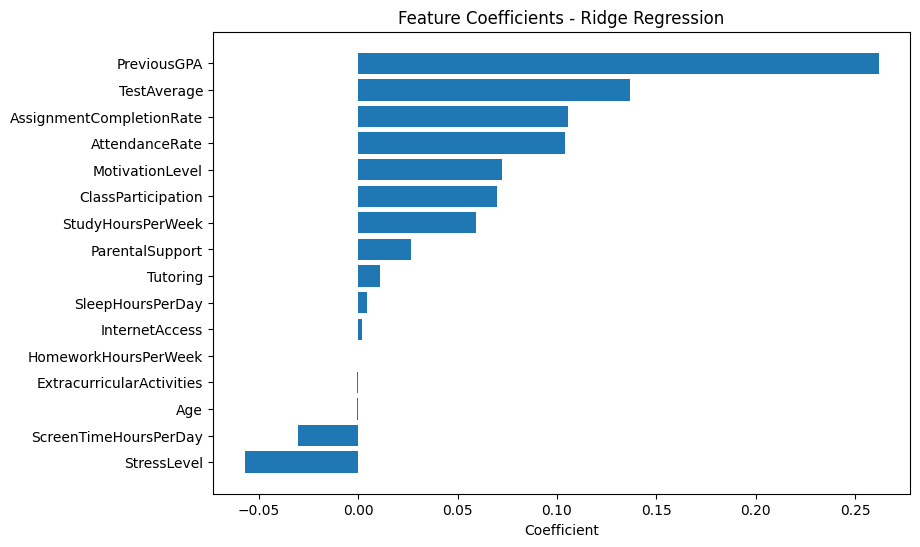

In [31]:
# Cell 31: Feature importance or coefficients
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    estimator = best_model.named_steps['model']
    importance_df = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': estimator.feature_importances_
    }).sort_values('Importance', ascending=False)
    display(importance_df)

    plt.figure(figsize=(9, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.gca().invert_yaxis()
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()
else:
    estimator = best_model.named_steps['model']
    coef_df = pd.DataFrame({
        'Feature': FEATURES,
        'Coefficient': estimator.coef_,
        'Absolute_Coefficient': np.abs(estimator.coef_)
    }).sort_values('Absolute_Coefficient', ascending=False)
    display(coef_df)

    plt.figure(figsize=(9, 6))
    plot_df = coef_df.sort_values('Coefficient')
    plt.barh(plot_df['Feature'], plot_df['Coefficient'])
    plt.xlabel('Coefficient')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.show()

## Cross-validation

A 5-fold CV check on the training data gives a more stable estimate of model behavior. The test set remains separate.

In [32]:
# Cell 32: 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

print('CV R² scores:', np.round(cv_scores, 4))
print(f'Mean CV R²: {cv_scores.mean():.4f}')
print(f'Std CV R² : {cv_scores.std():.4f}')

CV R² scores: [0.721  0.7221 0.7256 0.7326 0.7265]
Mean CV R²: 0.7256
Std CV R² : 0.0041


## New student prediction

In [33]:
# Cell 33: Prediction function
def predict_student_gpa(student_data):
    input_df = pd.DataFrame([student_data])
    input_df = input_df[FEATURES]
    prediction = float(best_model.predict(input_df)[0])
    return float(np.clip(prediction, 0, 4))

print('Prediction function ready.')

Prediction function ready.


In [34]:
# Cell 34: Example new student
new_student = {
    'Age': 20,
    'StudyHoursPerWeek': 20,
    'AttendanceRate': 85,
    'AssignmentCompletionRate': 90,
    'PreviousGPA': 3.00,
    'TestAverage': 75,
    'ClassParticipation': 8,
    'HomeworkHoursPerWeek': 10,
    'SleepHoursPerDay': 7,
    'ScreenTimeHoursPerDay': 4,
    'ParentalSupport': 2,
    'MotivationLevel': 4,
    'StressLevel': 2,
    'Tutoring': 1,
    'ExtracurricularActivities': 1,
    'InternetAccess': 1
}

predicted_gpa = predict_student_gpa(new_student)
print(f'Predicted GPA: {predicted_gpa:.2f}')

Predicted GPA: 2.24


## Student risk and recommendation layer

These thresholds are application rules, not model accuracy metrics. They provide a simple student-support layer after GPA prediction.

In [35]:
# Cell 35: Risk level and recommendations
def risk_and_recommendations(student, predicted_gpa):
    if predicted_gpa < 2.0:
        risk = 'High Risk'
    elif predicted_gpa < 2.5:
        risk = 'Moderate Risk'
    else:
        risk = 'Low Risk'

    recs = []
    if student['AttendanceRate'] < 75:
        recs.append('Improve attendance to at least 75%.')
    if student['StudyHoursPerWeek'] < 12:
        recs.append('Increase focused study hours each week.')
    if student['AssignmentCompletionRate'] < 80:
        recs.append('Complete assignments more consistently.')
    if student['TestAverage'] < 60:
        recs.append('Increase test preparation and revision time.')
    if student['SleepHoursPerDay'] < 6:
        recs.append('Improve sleep consistency.')
    if student['ScreenTimeHoursPerDay'] > 6:
        recs.append('Reduce non-academic screen time.')
    if student['StressLevel'] >= 4:
        recs.append('Use stress-management or academic-support resources.')
    if student['MotivationLevel'] <= 2:
        recs.append('Set small weekly study goals and track progress.')
    if not recs:
        recs.append('Maintain the current study routine and monitor progress.')

    return risk, recs

risk, recommendations = risk_and_recommendations(new_student, predicted_gpa)
print('Risk Level:', risk)
for item in recommendations:
    print('-', item)

Risk Level: Moderate Risk
- Maintain the current study routine and monitor progress.


In [36]:
# Cell 36: One-function student assessment
def assess_student(student_data):
    predicted = predict_student_gpa(student_data)
    risk, recs = risk_and_recommendations(student_data, predicted)
    return {
        'Predicted_GPA': round(predicted, 2),
        'Risk_Level': risk,
        'Recommendations': recs
    }

assessment = assess_student(new_student)
assessment

{'Predicted_GPA': 2.24,
 'Risk_Level': 'Moderate Risk',
 'Recommendations': ['Maintain the current study routine and monitor progress.']}

## Save the final model

In [37]:
# Cell 37: Save model, feature list, and metrics
MODEL_PATH = '/content/student_performance_model.pkl'
FEATURES_PATH = '/content/student_performance_features.pkl'
METRICS_PATH = '/content/student_performance_metrics.csv'

joblib.dump(best_model, MODEL_PATH)
joblib.dump(FEATURES, FEATURES_PATH)
results.to_csv(METRICS_PATH, index=False)

print('Saved:')
print(MODEL_PATH)
print(FEATURES_PATH)
print(METRICS_PATH)

Saved:
/content/student_performance_model.pkl
/content/student_performance_features.pkl
/content/student_performance_metrics.csv


In [38]:
# Cell 38: Load the saved model back and test it
loaded_model = joblib.load(MODEL_PATH)
loaded_prediction = float(loaded_model.predict(pd.DataFrame([new_student])[FEATURES])[0])
print(f'Loaded-model GPA prediction: {loaded_prediction:.2f}')

Loaded-model GPA prediction: 2.24


## Optional downloads from Google Colab

In [39]:
# Cell 39: Download exported files when needed
from google.colab import files

# Uncomment these one at a time when you want the files downloaded.
# files.download(MODEL_PATH)
# files.download(FEATURES_PATH)
# files.download(METRICS_PATH)

## Final report

The project uses the untouched test set for the final reported regression metrics. Do not describe R² as classification accuracy. The custom tolerance percentage is only a user-friendly extra metric.

In [40]:
# Cell 40: Final report
within_030 = tolerance_accuracy(y_test, best_test_pred, 0.30)

print('=' * 70)
print('AI-DRIVEN STUDENT PERFORMANCE PREDICTION SYSTEM')
print('=' * 70)
print('Best model       :', best_model_name)
print(f"Test R²          : {final_metrics['R2']:.4f}")
print(f"Test MAE         : {final_metrics['MAE']:.4f}")
print(f"Test RMSE        : {final_metrics['RMSE']:.4f}")
print(f"Within ±0.30 GPA : {within_030:.2f}%")
print(f"Mean CV R²       : {cv_scores.mean():.4f}")

AI-DRIVEN STUDENT PERFORMANCE PREDICTION SYSTEM
Best model       : Ridge Regression
Test R²          : 0.7214
Test MAE         : 0.1760
Test RMSE        : 0.2207
Within ±0.30 GPA : 82.33%
Mean CV R²       : 0.7256


In [41]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load(
    "/content/student_performance_model.pkl"
)

features = joblib.load(
    "/content/student_performance_features.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [42]:
def predict_student_performance(student_data):

    student_df = pd.DataFrame(
        [student_data],
        columns=features
    )

    predicted_gpa = model.predict(student_df)[0]

    predicted_gpa = np.clip(
        predicted_gpa,
        0,
        4
    )

    # Risk level
    if predicted_gpa < 2.0:
        risk = "High Risk"
    elif predicted_gpa < 2.5:
        risk = "Moderate Risk"
    elif predicted_gpa < 3.0:
        risk = "Low Risk"
    else:
        risk = "Good Performance"

    return predicted_gpa, risk

In [43]:
def generate_recommendations(student):

    recommendations = []

    if student["StudyHoursPerWeek"] < 10:
        recommendations.append(
            "Increase weekly study hours."
        )

    if student["AttendanceRate"] < 75:
        recommendations.append(
            "Improve class attendance."
        )

    if student["AssignmentCompletionRate"] < 80:
        recommendations.append(
            "Complete assignments more consistently."
        )

    if student["TestAverage"] < 60:
        recommendations.append(
            "Focus on test preparation and revision."
        )

    if student["SleepHoursPerDay"] < 6:
        recommendations.append(
            "Maintain a healthier sleep schedule."
        )

    if student["ScreenTimeHoursPerDay"] > 6:
        recommendations.append(
            "Reduce unnecessary screen time."
        )

    if student["StressLevel"] >= 4:
        recommendations.append(
            "Work on stress management and study planning."
        )

    if student["MotivationLevel"] <= 2:
        recommendations.append(
            "Set small academic goals to improve motivation."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Maintain the current academic habits."
        )

    return recommendations

In [44]:
student = {
    "Age": 20,
    "StudyHoursPerWeek": 20,
    "AttendanceRate": 85,
    "AssignmentCompletionRate": 90,
    "PreviousGPA": 3.0,
    "TestAverage": 75,
    "ClassParticipation": 8,
    "HomeworkHoursPerWeek": 10,
    "SleepHoursPerDay": 7,
    "ScreenTimeHoursPerDay": 4,
    "ParentalSupport": 2,
    "MotivationLevel": 4,
    "StressLevel": 2,
    "Tutoring": 1,
    "ExtracurricularActivities": 1,
    "InternetAccess": 1
}

print("Student data created.")

Student data created.


In [45]:
predicted_gpa, risk = predict_student_performance(
    student
)

recommendations = generate_recommendations(
    student
)

print("=" * 60)
print("AI STUDENT PERFORMANCE PREDICTION")
print("=" * 60)

print(f"Predicted GPA : {predicted_gpa:.2f}")
print(f"Risk Level    : {risk}")

print("\nRecommendations:")
for i, recommendation in enumerate(
    recommendations,
    1
):
    print(f"{i}. {recommendation}")

AI STUDENT PERFORMANCE PREDICTION
Predicted GPA : 2.24
Risk Level    : Moderate Risk

Recommendations:
1. Maintain the current academic habits.


In [46]:
def run_prediction():

    print("=" * 60)
    print("STUDENT PERFORMANCE PREDICTION SYSTEM")
    print("=" * 60)

    student = {}

    student["Age"] = float(input("Age: "))
    student["StudyHoursPerWeek"] = float(
        input("Study Hours Per Week: ")
    )
    student["AttendanceRate"] = float(
        input("Attendance Rate (%): ")
    )
    student["AssignmentCompletionRate"] = float(
        input("Assignment Completion Rate (%): ")
    )
    student["PreviousGPA"] = float(
        input("Previous GPA: ")
    )
    student["TestAverage"] = float(
        input("Test Average: ")
    )
    student["ClassParticipation"] = float(
        input("Class Participation: ")
    )
    student["HomeworkHoursPerWeek"] = float(
        input("Homework Hours Per Week: ")
    )
    student["SleepHoursPerDay"] = float(
        input("Sleep Hours Per Day: ")
    )
    student["ScreenTimeHoursPerDay"] = float(
        input("Screen Time Hours Per Day: ")
    )
    student["ParentalSupport"] = float(
        input("Parental Support: ")
    )
    student["MotivationLevel"] = float(
        input("Motivation Level: ")
    )
    student["StressLevel"] = float(
        input("Stress Level: ")
    )
    student["Tutoring"] = float(
        input("Tutoring (0/1): ")
    )
    student["ExtracurricularActivities"] = float(
        input("Extracurricular Activities (0/1): ")
    )
    student["InternetAccess"] = float(
        input("Internet Access (0/1): ")
    )

    predicted_gpa, risk = predict_student_performance(
        student
    )

    recommendations = generate_recommendations(
        student
    )

    print("\n" + "=" * 60)
    print("RESULT")
    print("=" * 60)

    print(f"Predicted GPA: {predicted_gpa:.2f}")
    print(f"Risk Level   : {risk}")

    print("\nRecommendations:")

    for i, recommendation in enumerate(
        recommendations,
        1
    ):
        print(f"{i}. {recommendation}")

In [47]:
run_prediction()

STUDENT PERFORMANCE PREDICTION SYSTEM
Age: 16
Study Hours Per Week: 7
Attendance Rate (%): 76
Assignment Completion Rate (%): 65
Previous GPA: 2.3
Test Average: 3
Class Participation: 5
Homework Hours Per Week: 4
Sleep Hours Per Day: 4
Screen Time Hours Per Day: 7
Parental Support: 1
Motivation Level: 1
Stress Level: 1
Tutoring (0/1): 1
Extracurricular Activities (0/1): 1
Internet Access (0/1): 1

RESULT
Predicted GPA: 0.54
Risk Level   : High Risk

Recommendations:
1. Increase weekly study hours.
2. Complete assignments more consistently.
3. Focus on test preparation and revision.
4. Maintain a healthier sleep schedule.
5. Reduce unnecessary screen time.
6. Set small academic goals to improve motivation.
